In [ ]:
! pip install git+https://github.com/openai/CLIP.git
! pip install PyDictionary
! pip install ftfy regex tqdm

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-4zyeo_gt
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-4zyeo_gt
  Resolved https://github.com/openai/CLIP.git to commit a1d071733d7111c9c014f024669f959182114e33
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import clip
from torch.nn.functional import cosine_similarity

import matplotlib.pyplot as plt
import copy
import random
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import numpy as np

from tqdm import tqdm
from PyDictionary import PyDictionary

# Create dictionary, load model

In [ ]:
english_dict = PyDictionary()

print(f'xylophone: {english_dict.meaning("xylophone")}')  # english_dict is a Python dictionary of English
print(type(english_dict.meaning("xylophone")))

word = 'xylophone'
dic = english_dict.meaning(word)
k  = dic.values()

xylophone: {'Noun': ['a percussion instrument with wooden bars tuned to produce a chromatic scale and with resonators; played with small mallets']}
<class 'dict'>


In [ ]:
# bitandbytes hugging face library, dinov2

def load():

    # Load the model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, preprocess = clip.load('ViT-B/32', device)

    # model = model.visual.float()
    cifar100 = torchvision.datasets.CIFAR100(root= './data', download = True, train = False)

    return cifar100, model, device, preprocess

In [ ]:
cifar100, model, device, preprocess = load()
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in cifar100.classes]).to(device)

Files already downloaded and verified


In [ ]:
#Encoded text
with torch.no_grad():
  text_features = model.encode_text(text_inputs)

text_features /= text_features.norm(dim=-1, p = 2, keepdim=True)

# Get description embeddings

In [ ]:
def get_best_words(c, sentence, words_yet, top_n = 3):

      # Tokenize the word and the sentence

      label_token = clip.tokenize(c).to(device)
      sentence_token = clip.tokenize(sentence).to(device)

      words = sentence.split()

      # Elements to remove
      elements_to_remove = [c, 'to', 'if', 'of', 'a', 'the', 'and', 'in', 'or']
      elements_to_remove.extend(words_yet)

      # Remove specified elements
      words = [x for x in words if x not in elements_to_remove]

      words = list(set(words)) # remove duplicates

      if len(words) == 0: return None, None

      words_tokens = torch.cat([clip.tokenize(f'A photo of: {word}') for word in words]).to(device)

      # Embed the tokens
      with torch.no_grad():

          label_embedding = model.encode_text(label_token)
          sentence_embedding = model.encode_text(sentence_token)
          words_embedding = model.encode_text(words_tokens)


      words_embedding /= words_embedding.norm(dim = -1, p = 2, keepdim=True)
      sentence_embedding /= sentence_embedding.norm(dim = -1, p = 2, keepdim=True)

      words_embedding = 0.7 * words_embedding + 0.3 * sentence_embedding


      # Compute cosine similarity
      sim = label_embedding @ words_embedding.T

      pick = min([top_n, len(words)])
      _, top_indices = torch.topk(sim, pick)

      top_indices = top_indices.squeeze()

      if top_indices.numel() == 1: return words_embedding, words

      indices = [top_indices[i].item() for i in range(top_indices.shape[0]) ]

      return words_embedding[indices,:], [words[i] for i in indices]

In [ ]:
def flatten_dictionary(model, c, input_dict, text_feature, top_n = 3):

    tensors = []
    words = []

    for key, inner_dict in input_dict.items():
        for values in inner_dict.values():

            for value in values:

              tensor, word = get_best_words(c, value, words, top_n)

              if tensor != None:
                tensors.append(tensor)
                words.extend(word)


    tensors = torch.vstack(tensors)

    if len(words) == 3:
        return tensors, words

    elif len(words) > 3:

      sim = text_feature @ tensors.T

      pick = min([top_n, tensors.shape[0]])
      _, top_indices = torch.topk(sim, pick)

      top_indices = top_indices.squeeze()
      indices = [top_indices[i].item() for i in range(top_indices.shape[0]) ]

      return tensors[indices,:], [words[i] for i in indices]

    else:
      raise ValueError(f"Not enough words found for label: {c}")

In [ ]:
tensors = []

for i in tqdm(range(len(cifar100.classes))):

    c = cifar100.classes[i]

    words = c.split('_')
    d_word = PyDictionary(words) # this is extremely slow. Luckily we just need to do it once.

    tensor, _ = flatten_dictionary(model, c, d_word.getMeanings(), text_features[i,:], top_n = 5)
    tensors.append(tensor)


100%|██████████| 100/100 [01:05<00:00,  1.52it/s]


In [ ]:
# It's better to consider the embeddings as column vectors. For linear algebra purposes.

descript_embeddings = torch.stack(tensors).permute(0, 2, 1)
print(descript_embeddings.shape)

torch.Size([100, 512, 5])


# Plot tensor

In [ ]:
def plot_tensor(tensor_list, title = None, color = 'skyblue'):

    n = len(tensor_list)

    if n == 1:

      tensor = tensor_list[0]

      indices = torch.arange(len(tensor)).to(device)
      plt.bar(indices.cpu().detach().numpy(), tensor.detach().cpu().numpy(), color = color)
      plt.xlabel('Index')
      plt.ylabel('Value')
      plt.title(title)
      plt.grid(True)
      plt.show()

    else:
      fig, axs = plt.subplots(1, n, figsize=(15, 5))

      for i in range(n):
        data = tensor_list[i]
        indices = torch.arange(len(data)).to(device)
        # Plot histograms
        axs[i].bar(indices.cpu().detach().numpy(), data.cpu().detach().numpy(), color='blue', alpha=0.5)
        axs[i].set_title(title[i])
        axs[i].set_xlabel('Index')
        axs[i].set_ylabel('Value')

      # Adjust layout
      plt.tight_layout()

      # Show the plot
      plt.show()

# CLIP predictions

In [ ]:
def pick_candidates(tensor, classifier, num_candidates):

    _, top_indices = torch.topk(classifier, num_candidates)
    candidates = torch.squeeze(tensor[top_indices])

    return candidates, top_indices

In [ ]:
def predict(model, image, text_features, label):

    model.eval()
    image_prep = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():

        image_features = model.encode_image(image_prep) # image features contains the embeddings of all the elements of the class.
        image_features = image_features / image_features.norm(dim = -1, keepdim = True)
        outputs = 100.0 * image_features @ text_features.T

        _, predicted = outputs.max(1)
        confidence = nn.functional.softmax(outputs,dim=1).squeeze()[predicted].item()

    correctness = 1 if predicted.item() == label else 0

    return correctness# , confidence

# dictionary prediction

In [ ]:
def descript_prediction(model, image, text_features, descript_features, label, temperature = 10):

    model.eval()
    image_prep = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():

        image_features = model.encode_image(image_prep) # image features contains the embeddings of all the elements of the class.
        image_features = image_features / image_features.norm(dim = -1, p = 2, keepdim = True)
        class_outputs = image_features @ text_features.T

        _, predicted = class_outputs.max(1)
        class_outputs = class_outputs.squeeze()


    candidates, top_indices = pick_candidates(text_features, class_outputs, num_candidates = 5)
    descript_candidates = descript_features[top_indices].squeeze()

    # covariance of the candidates. Matrix is always s.p.d. then its determinant is > 0.
    candidates = candidates.T.to(torch.float32)
    Sigma_c = torch.det( torch.matmul(candidates.T, candidates) )
    adaptive_temp = -np.log(Sigma_c.item()) * np.log(candidates.shape[0])

    class_outputs = class_outputs * adaptive_temp

    projections = []
    projections_img = []

    for i in range(descript_candidates.shape[0]):

      X = descript_candidates[i].to(torch.float32)

      # Projection matrix: X (X^T X)^-1 X^T
      gram_inv = torch.linalg.inv( torch.matmul(X.T, X))
      P = torch.matmul( torch.matmul(X, gram_inv), X.T)

      project_img = torch.matmul(P, image_features.T.to(torch.float32))

      projections.append( project_img.norm(dim = 0, p = 2, keepdim = True))
      projections_img.append(project_img.T)



    projections_img = torch.vstack(projections_img).T.to(torch.float32)
    Sigma_c = torch.det( torch.matmul(projections_img.T, projections_img) )
    adaptive_temp = -np.log(Sigma_c.item()) * np.log(projections_img.shape[0])

    projections = torch.vstack(projections).squeeze() * np.sqrt(adaptive_temp) # add some temperature
    proj_prob = torch.nn.functional.softmax(projections, dim = 0)


    class_prob = torch.nn.functional.softmax( class_outputs[top_indices.squeeze()], dim = 0)

    output_prob = 0.6 * class_prob + 0.4 * proj_prob

    max, predicted_candidate = output_prob.max(0)
    predicted = top_indices[predicted_candidate]

    correctness = 1 if predicted == label else 0

    return correctness



# Let's go testing

In [ ]:
n = 1
correct_descript = 0
correct_clip = 0

changed_for_good = 0
changed_for_bad  = 0

start = random.randint(0, 5000)
start = 0
print(f'Starting at {start}')


for i in tqdm(range(n)):

  image, label = cifar100[i]
  cc = predict(model, image, text_features, label)


  cd = descript_prediction(model, image, text_features, descript_embeddings, label, temperature = 10)

  correct_clip += cc
  correct_descript += cd

  if cc == 1 and cd == 0: changed_for_bad += 1
  if cc == 0 and cd == 1: changed_for_good += 1


print(f'Clip: {correct_clip}. dictionary: {correct_descript}')
print(f'Changed for bad: {changed_for_bad}. Changed for good: {changed_for_good}.')

print(f'Clip accuray: {correct_clip / n :.3%}. Dictionary accuracy: {correct_descript / n :.3%}')


Starting at 0


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
100%|██████████| 1/1 [00:01<00:00,  1.22s/it]

Clip: 0. dictionary: 0
Changed for bad: 0. Changed for good: 0.
Clip accuray: 0.000%. Dictionary accuracy: 0.000%


# Descriptive labels, generalized similarities, adaptive temperature: exploiting CLIP's strengths and experimenting with mathematical tools


In order to improve prediction at test time, lots of algorithms use the informations coming from augmentations of the image itself. But what about switching the roles and augment the labels available? It may sound easy, but there are a few obstacles to overcome.

The first problem relies on the nature of the model itself, that may not allow additional labels. Fortunately this is not the case in the current framework as CLIP provides embeddings for *any* string, whether it's a word or a sentence. So it's definitely worth exploiting this functionality.

The second issue to resolve, which is where our work focused on, is *which labels to choose*. CoOp relies on learnable parameters to better suit prompts to the images. However, learnable parameters implies that a model needs to be trained on some dataset. Apart from the time spent training such a structure, CoOp do not performs well on classes that weren't present in the training set, leading to weak generalization if the dataset isn't big enough. To address this problem, we try to go through a simpler path that allows to inject additional labels for every class and leverages a couple of linear algebra notions.

## Looking for additional labels

The simplest way of having additional (and *meaningful*) information about a class, i.e. a word, is to describe it. For example "boy" can be described by words such as "young", "male", "school". From here on the trajectory starts to be quite clear: using these descriptions to compute the similarity with the image. High values will suggest that "boy" is the label to go, low values the other way around.

Clearly hardcoding such labels is not the preferred option, as there's a perfect tool (along with a Python library) that for every word is able to give meaningful descriptions of it: the dictionary. For every label, look at the words coming out from the definition and embed them. Then, in the same fashon as *entropyboosting*, keep only the words closest to the class embedding. Along with this, consider also the embedding of the whole definition and use it as *context vector* to slightly shift the word embeddings. The set of selected and shifted words will be called *descriptive labels*.

The first and most straightforward advantage of such a method is the *speed*: these computations needs to be performed only once before testing time.

## Projections as similarity measures

Given those extra labels, how to exploit them? The idea we pursued is, like *EB* method, to average between the probability distribution given by the original label and the one given by the descriptive ones.

To compute the latter probability distribution, some linear algebra is required. In CLIP's framework all vectors are normalized, hence the cosine similarity coincides with the scalar product. Since, yet again, vectors are all normalized:

$$ (x,y) x = \Pi _{\text{span} \langle x \rangle } (y)
$$

the scalar product is hence the coefficient of the projection of $y$ into the subspace generated by $x$. Now, instead of the single vector $x$, consider $x_1 \ldots x_n$: the descriptive labels. $\text{span} \langle x_1, \ldots x_n\rangle$ is the subspace generated by $x_i$, which represents *vectors semantically related to all the descriptive labels*. The target now is to project the image onto this space. Luckily the projection mapping has the following nice shape:

$$\Pi_{\text{span} \langle x_1, \ldots x_n \rangle} = X (X^T X)^{-1} X^T$$

where $X$ is the matrix whose columns are $x_i$. Therefore the $length$ of the projection of the image in this space corresponds to how much it is semantically related to the descriptive features of the class.

Visually, it looks like this:

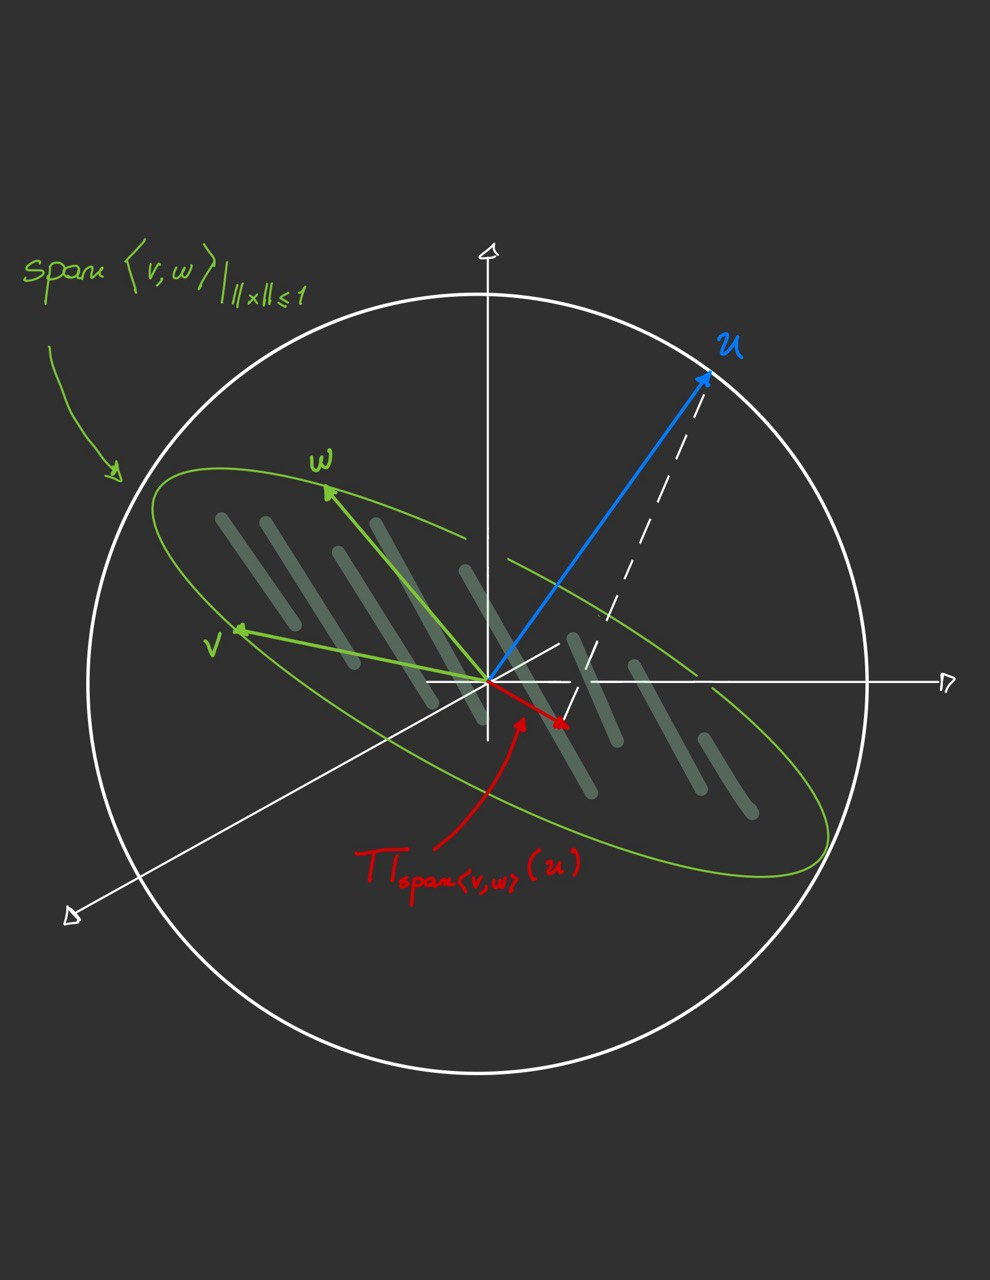

A high value of the length of the projection means that the image embedding aligns well with the descripting subspace. In other words, thanks to the Orthogonal decomposition theorem, the value

$$ \bigg\| \Pi_{\text{span}\langle (x_i)_i \rangle} (img\_embedding) \bigg\|^2$$

represents *the extent to which the features $(x_i)_i$ contribute to forming the vector $img\_embedding$*.

## Getting the output probability

In the same fashon of *entropy boost*, the output probability is a convex combination between the probability of the basic similarities between the image and the best scoring candidates, and the probability distribution whose logits are the length of the projections descripted in the previous section.

## Adaptive temperature

As mentioned before, cosine similarities applied in CLIP are nothing but scalar products. As vectors lie in a high dimensional ($512$) space, due to the curse of dimensionality distances compress, resulting in logits pretty similar one to each other. It's not a suprise than that in the out-of-the-box implementation of CLIP values are multiplied by a factor of 100:
```
similarities = 100.0 * text_features @ image_features.T
```
which dilates outputs, resulting in a significant reduction of entropy when the softmax is later on applied. CLIP itself provides a learnt temperature parameter to also deal with this problem.

This is a feature not to underestimate, and it is important to handle it with care when comparing two probability distributions: putting *too much* temperature and one of those may highly propend for a value - which can lead to overconfidence over a wrong label without being able to recover from it when averaging distributions-; *too little* to become noninformative, just because of some artificial hyperparameter reduces by a certain amount the entropy. Low entropy is desirable, too low not that much.

Trying to have an adaptive temperature parameter may help to stay in the right in-between. *Then why not trying to reverse the problem?* Why not fixing the entropy to then find the correct temperature level? Keeping under control such a delicate parameter may help in avioding the dangerous cases mentioned above.

## Figuring out the math

Given a set of logits $(x_i)_i$ and the corresponding probability distribution (output of the softmax function) $(p_i)_i$, then the target is to have
$$H(p | \tau) = \beta$$
where $\tau$ is the temperature parameter, and $\beta$ is the fixed entropy value (hyperparameter). Then

$$
\begin{aligned}
H(p | \tau) &= - \sum_i p_i \log(p_i) \\
&= -\sum_i  \frac{e^{x_i \tau}}{\sum_j e^{x_j \tau}}
\log \biggl( \frac{e^{x_i \tau}}{\sum_j e^{x_j \tau}} \biggr) \\
&= - \frac{1}{\sum_j e^{x_j \tau}}\sum_i e^{x_i \tau} \biggl( \log(e^{x_i \tau}) - \log \Bigl( \sum_j e^{x_j \tau} \Bigr) \biggr) \\
&= - \frac{1}{\sum_j e^{x_j \tau}} \biggl( \sum_i e^{x_i \tau}x_i \tau -
\sum_i e^{x_i \tau}\log \Bigl( \sum_j e^{x_j \tau} \Bigr)  \biggr)\\
&= - \frac{\sum_i e^{x_i \tau} x_i \tau}{\sum_j e^{x_j \tau}} + \frac{\sum_i e^{x_i \tau}}{\sum_j e^{x_j \tau}}\log \sum_j e^{x_j \tau} \\
&= - \frac{\sum_i e^{x_i \tau} x_i \tau}{\sum_j e^{x_j \tau}} + \log \sum_j e^{x_j \tau}
\end{aligned}
$$

The second term of the latter sum is the *LSE (LogSumExp)* function applied to vector $x$, for which holds the inequality:

$$
\max_i \{ \tau x_i \} \leq \text{LSE}(x) \leq \max_i \{ \tau x_i \} + \log(n)
$$
where $n$ is the number of components of $x$. A reasonable approximation is given by
$$
\log \sum_j e^{x_j \tau} \approx \max_i \{ \tau x_i \} + \frac{\log(n)}{2}
$$
Regarding the first term, first recall that the logits $x_i = ( img, c_i)$ are the scalar products between the image and the class embeddings, which are both normalized, thanks to Cauchy-Schwartz inequality:
$$
|x_i| = |(img, c_i)| \leq \|img\|\|c_i\| = 1
$$
and it is equal iif $img = c_i$. Moreover, it holds that as the dimension of the embedding space $d \rightarrow \infty $, then $x_i \rightarrow 0$ $a.s.$ ([proof here](https://math.stackexchange.com/questions/995623/why-are-randomly-drawn-vectors-nearly-perpendicular-in-high-dimensions) ).
This means that $x_i$ in general is quite small. For these reasons, makes sense to approximate the exponentials with their Taylor's expansions:

$$
\frac{\sum_i e^{x_i \tau} x_i \tau}{\sum_j e^{x_j \tau}} \approx
\frac{\sum_i x_i\tau + (x_i\tau)^2 + \frac{(x_i\tau)^3}{2} + \frac{(x_i\tau)^4}{6}}{\sum_j 1 + (x_j\tau) + \frac{(x_j\tau)^2}{2} + \frac{(x_j\tau)^3}{6}}
$$

For this work, we stopped at third order Taylor expansion. Finally, the above equation can be approximated as follows:

$$
\frac{\sum_i x_i\tau + (x_i\tau)^2 + \frac{(x_i\tau)^3}{2} + \frac{(x_i\tau)^4}{6}}{\sum_j 1 + (x_j\tau) + \frac{(x_j\tau)^2}{2} + \frac{(x_j\tau)^3}{6}} + \max_i \{ \tau x_i \} + \frac{\log(n)}{2} - \beta = 0
$$

This equation can be then thrown into a numerical solver to get an approximation of $\tau$. Unfortunately those steps were necessary as the numerical solvers we tried didn't work using the original expression for $H$.The hyperparameter set for $\beta$ is $\frac{1}{2}\log(2\pi e)$, which is the entropy of the standard gaussian distribution.